<a href="https://colab.research.google.com/github/nur21horin/machine_learning/blob/main/Nlp_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv('/content/train.txt',sep=';',header=None,names=['text','emotion'])

In [6]:
df.head()

,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


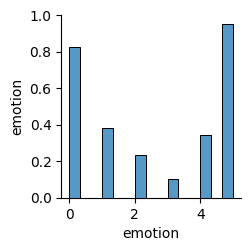

In [28]:
sns.pairplot(df)

In [7]:
df.isnull().sum()

,0
text,0
emotion,0


In [8]:
unique_emotions=df['emotion'].unique()
emotion_numbers={}
i=0
for emo in unique_emotions:
  emotion_numbers[emo]=i
  i+=1
df['emotion']=df['emotion'].map(emotion_numbers)

In [9]:
df

,text,emotion
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,1
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,1
...,...,...
15995,i just had a very brief time in the beanbag an...,0
15996,i am now turning and i feel pathetic that i am...,0
15997,i feel strong and good overall,5
15998,i feel like this was such a rude comment and i...,1


In [10]:
df['text']=df['text'].apply(lambda x: x.lower())

In [11]:
import string
def remove_punc(txt):
  return txt.translate(str.maketrans('','',string.punctuation))

In [12]:
df['text']=df['text'].apply(remove_punc)

In [13]:
def remove_numbers(txt):
  new=""
  for i in txt:
    if not i.isdigit():
      new=new+i
  return new
df['text']=df['text'].apply(remove_numbers)

In [14]:
def remove_emojis(txt):
  new=""
  for i in txt:
    if i.isascii():
      new+=i
  return new
df['text']=df['text'].apply(remove_emojis)

In [15]:
import nltk

In [16]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [17]:
stop_words=set(stopwords.words('english'))
len(stop_words)

198

In [18]:
df.loc[1]['text']

'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake'

In [19]:
def remove(txt):
  words=txt.split()
  cleaned=[]
  for i in words:
    if not i in stop_words:
      cleaned.append(i)
  return " ".join(cleaned)


In [20]:
df['text']=df['text'].apply(remove)

In [21]:
df.loc[1]['text']

'go feeling hopeless damned hopeful around someone cares awake'

In [22]:
df.head()

,text,emotion
0,didnt feel humiliated,0
1,go feeling hopeless damned hopeful around some...,0
2,im grabbing minute post feel greedy wrong,1
3,ever feeling nostalgic fireplace know still pr...,2
4,feeling grouchy,1


In [23]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(df['text'],df['emotion'],test_size=0.20,random_state=42)
print(X_train.shape)
print(X_test.shape)

(12800,)
(3200,)


In [25]:
df.corr(numeric_only=True)

,emotion
emotion,1.0


In [26]:
import seaborn as sns

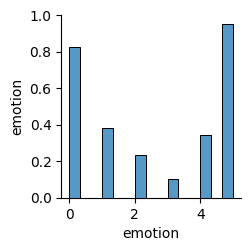

In [27]:
sns.pairplot(df)